In [1]:
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
fitting_data = pd.read_csv('get_fitting_data_chinchilla.csv')
m = fitting_data['d_model'].values
ell = fitting_data['n_layers'].values
D = fitting_data['num_tokens'].values
losses = fitting_data['loss'].values

nr_of_models_excluded = 40 # 40 is good

sorted_losses = sorted(losses)
if nr_of_models_excluded == 0:
    indices = list(range(len(m)))
else:
    sorted_losses = sorted(losses)
    indices = [i for i in range(len(m)) if losses[i] < sorted_losses[-nr_of_models_excluded]]

m = torch.tensor(m[indices])
ell = (torch.tensor(ell[indices])-2) * 100
D = torch.tensor(D[indices]) / 1e+6
losses = torch.tensor(losses[indices])

slope: 0.6592104821330464, intercept: 2.772874036544207


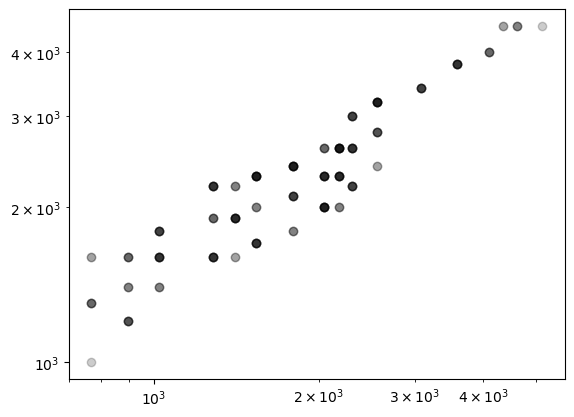

In [3]:
slope, intercept = np.polyfit(torch.log(m).numpy(), torch.log(ell).numpy(), 1)
print(f'slope: {slope}, intercept: {intercept}')
plt.plot(m, ell, 'o', alpha=0.2, color='black')
plt.xscale('log')
plt.yscale('log')

In [4]:
# lnc_m, lnc_ell, lnc_D, a_m, a_ell, a_D, lnE
#params = nn.Parameter(torch.tensor([4.0, 4.0, 4.0, 1.0, 1.0, 0.33, np.log(1.69)]))
coeffs = nn.Parameter(torch.tensor([np.log(200), np.log(200), np.log(10)]))
exponents = nn.Parameter(torch.tensor([1.0, 1.0, 0.33]))
E = nn.Parameter(torch.tensor(1.69))
num_epochs = 50000
risks = []
optimizer = torch.optim.Adam([{'params': coeffs, 'lr': 0.005}, 
                              {'params': exponents, 'lr': 0.0005}, 
                              {'params': E, 'lr': 0.005}])

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Extract parameters
    lnc_m, lnc_ell, lnc_D = coeffs
    a_m, a_ell, a_D = exponents
    
    # Calculate the model output

    expected_log_loss = ((lnc_D - a_D * D.log()).exp() + (lnc_m - a_m * m.log()).exp() + (lnc_ell - a_ell * ell.log()).exp() + E).log()

    risk = (losses.log() - expected_log_loss).pow(2).mean() * 100
    risks.append(risk.item())
    
    # Backpropagation
    risk.backward()
    
    # Update parameters
    optimizer.step()

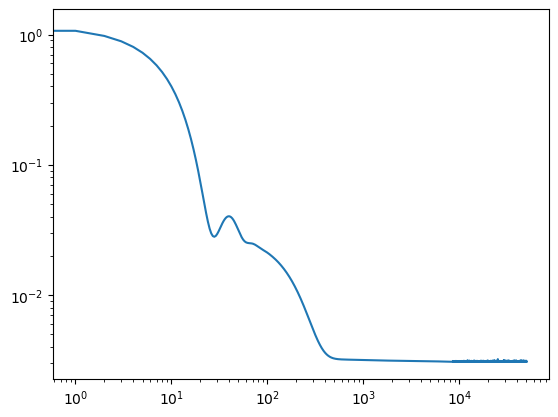

In [5]:
plt.plot(risks)
plt.yscale('log')
plt.xscale('log')

In [6]:
risks[-1]

0.003061507719156697

In [7]:
print("Fitted parameters:")
print(f"c_m: {coeffs[0].exp().item()}, a_m: {exponents[0].item()}")
print(f"c_ell: {coeffs[1].exp().item()}, a_ell: {exponents[1].item()}")
print(f"c_D: {coeffs[2].exp().item()}, a_D: {exponents[2].item()}")
print(f"E: {E.item()}")

Fitted parameters:
c_m: 300.988021816479, a_m: 0.9599189162254333
c_ell: 413.69695850058315, a_ell: 1.0660876035690308
c_D: 8.485901100690645, a_D: 0.2988601326942444
E: 1.7442079782485962


In [8]:
# Calculate standard errors using the Jacobian
# Enable gradient computation for all parameters
coeffs.requires_grad = True
exponents.requires_grad = True
E.requires_grad = True

# Calculate residuals
lnc_m, lnc_ell, lnc_D = coeffs
a_m, a_ell, a_D = exponents
expected_log_loss = ((lnc_D - a_D * D.log()).exp() + (lnc_m - a_m * m.log()).exp() + (lnc_ell - a_ell * ell.log()).exp() + E).log()
residuals = losses - expected_log_loss.exp()
relative_residuals = residuals / losses

# Number of observations and parameters
n = len(losses)
p = 7  # total number of parameters (3 coeffs + 3 exponents + 1 E)

# Calculate Jacobian matrix using autograd
jacobian = []
for i in range(n):
    grads = torch.autograd.grad(residuals[i], [coeffs, exponents, E], 
                                 retain_graph=True, create_graph=False)
    # Flatten all gradients into a single vector
    grad_vec = torch.cat([grads[0], grads[1], grads[2].unsqueeze(0)])
    jacobian.append(grad_vec.detach())

J = torch.stack(jacobian)  # Shape: (n, p)

# Calculate residual variance (Mean Squared Error)
residual_variance = (residuals.detach() ** 2).sum() / (n - p)
print(f"Residual variance: {residual_variance.item()}")

# Calculate covariance matrix: Cov = residual_variance * (J^T J)^(-1)
JTJ = J.T @ J
try:
    covariance_matrix = residual_variance * torch.linalg.inv(JTJ)
    
    # Standard errors are the square root of the diagonal elements
    standard_errors = torch.sqrt(torch.diag(covariance_matrix))
    
    print("Standard errors of the estimates:")
    print(f"c_D: {standard_errors[2].item()}")
    print(f"c_m: {standard_errors[0].item()}")
    print(f"c_ell: {standard_errors[1].item()}")
    print(f"a_D: {standard_errors[5].item()}")
    print(f"a_m: {standard_errors[3].item()}")
    print(f"a_ell: {standard_errors[4].item()}")
    print(f"E: {standard_errors[6].item()}")
    
except RuntimeError as e:
    print(f"Could not invert matrix: {e}")
    print("Using pseudo-inverse instead...")
    covariance_matrix = residual_variance * torch.linalg.pinv(JTJ)
    standard_errors = torch.sqrt(torch.diag(covariance_matrix))
    
    print("Standard errors of the estimates (using pseudo-inverse):")
    print(f"c_D: {standard_errors[2].item()}")
    print(f"c_m: {standard_errors[0].item()}")
    print(f"c_ell: {standard_errors[1].item()}")
    print(f"a_D: {standard_errors[5].item()}")
    print(f"a_m: {standard_errors[3].item()}")
    print(f"a_ell: {standard_errors[4].item()}")
    print(f"E: {standard_errors[6].item()}")

Residual variance: 0.0002023934570013089
Standard errors of the estimates:
c_D: 0.08909776916182344
c_m: 0.5006767496037277
c_ell: 1.591338712014129
a_D: 0.013926121497994043
a_m: 0.08158169606084421
a_ell: 0.24231349893827228
E: 0.02604941962410627


In [9]:
residuals.detach().abs().mean()

tensor(0.0101, dtype=torch.float64)

In [10]:
relative_residuals.detach().abs().mean()

tensor(0.0040, dtype=torch.float64)

In [11]:
min_loss_idx = torch.argmin(losses)
print(f"min loss at index: {min_loss_idx}, loss value: {losses[min_loss_idx].item()}")
min_loss_m = coeffs[0].exp().item() / m[min_loss_idx].item() ** exponents[0].item()
min_loss_ell = coeffs[1].exp().item() / ((ell[min_loss_idx].item()) ** exponents[1].item())
min_loss_D = coeffs[2].exp().item() / (D[min_loss_idx].item() ** exponents[2].item())
print(f"min loss contributions - m: {min_loss_m}, ell: {min_loss_ell}, D: {min_loss_D}")

min loss at index: 202, loss value: 2.0773942450664395
min loss contributions - m: 0.11658539092473193, ell: 0.06314215676929424, D: 0.192460722520026


Text(0, 0.5, 'Loss (depth part)')

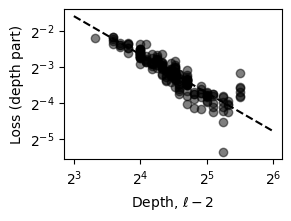

In [12]:
p_indices = [i for i in range(len(ell)) if ell[i] < 5000] # all data
plt.figure(figsize=(2.8,2.1), constrained_layout=True)
plt.plot(ell[p_indices].numpy() / 100, losses[p_indices].numpy() - coeffs[0].exp().item() / m[p_indices].numpy() ** exponents[0].item()
         - coeffs[2].exp().item() / D[p_indices].numpy() ** exponents[2].item() - E.item(), 'ok', alpha = 0.5)
plt.plot(np.arange(8, 64), coeffs[1].exp().item() / (np.arange(8, 64)*100) ** exponents[1].item(), 'k--')
plt.xscale('log', base = 2)
#plt.ylim(2**(-5.1), None)
plt.yscale('log', base = 2)
plt.xlabel(r'Depth, $\ell-2$')
plt.ylabel('Loss (depth part)')
#plt.savefig('../figures/loss_vs_depth_depth_part.png', dpi = 300)

Text(0, 0.5, 'Loss (width part)')

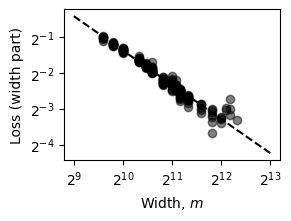

In [13]:
p_indices = [i for i in range(len(ell)) if ell[i] < 5000] # all data
plt.figure(figsize=(2.8,2.1), constrained_layout=True)
plt.plot(m.numpy(), losses.numpy() - coeffs[1].exp().item() / ell.numpy() ** exponents[1].item()
         - coeffs[2].exp().item() / D.numpy() ** exponents[2].item() - E.item(), 'ok', alpha = 0.5)
plt.plot(np.arange(2**9, 2**13), coeffs[0].exp().item() / (np.arange(2**9, 2**13)) ** exponents[0].item(), 'k--')
plt.xscale('log', base = 2)
#plt.ylim(2**(-5.1), None)
plt.yscale('log', base = 2)
plt.xlabel(r'Width, $m$')
plt.ylabel('Loss (width part)')
#plt.savefig('../figures/loss_vs_depth_depth_part.png', dpi = 300)

Text(0, 0.5, 'Loss (dataset part)')

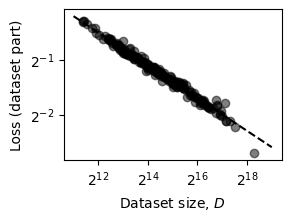

In [ ]:
plt.figure(figsize=(2.8,2.1), constrained_layout=True)
plt.plot(D.numpy(), losses.numpy() - coeffs[1].exp().item() / ell.numpy() ** exponents[1].item()
         - coeffs[0].exp().item() / m.numpy() ** exponents[0].item() - E.item(), 'ok', alpha = 0.5)
plt.plot(np.arange(2**11, 2**19), coeffs[2].exp().item() / (np.arange(2**11, 2**19)) ** exponents[2].item(), 'k--')
plt.xscale('log', base = 2)
#plt.ylim(2**(-5.1), None)
plt.yscale('log', base = 2)
plt.xlabel(r'Dataset size, $D$')
plt.ylabel('Loss (dataset part)')
#plt.savefig('../figures/loss_vs_depth_depth_part.png', dpi = 300)